<div style="text-align: center; margin-top: 30px; margin-bottom: 35px;">
    <h1>Sentiment Analysis of Consumer Perceptions Towards Sustainability-Related Products, Brands and Practices Using VADER and Machine Learning</h1>
    <h3>MSc Business Analytics - Traditional Research Project</h3>
</div>

### 1. Importing Librarires:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings

warnings.filterwarnings("ignore")

# NLP libraries
import nltk

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Loading the Dataset:

In [2]:
file_path = "EcoForumFeedbackDataset.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="NLP_Sustainable"
)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (3523, 6)


,date,source,topic,sentiment,comment,language
0,2014-12-04,Kaskus,Less Sustainable Product,netral,"Direktur Executive Indonesia Properti Watch, A...",ID
1,2014-12-04,Kaskus,Less Sustainable Product,negatif,goreng2ab developer,ID
2,2014-12-04,Kaskus,Less Sustainable Product,negatif,"apa enggak anjlok, harganya pun gila2an\nbulan...",ID
3,2015-04-06,Kaskus,Less Sustainable Product,negatif,goreng terus aja bray.....depan kosan gw ada r...,ID
4,2018-07-16,Kaskus,Eco-Friendly Business Ideas,netral,"Pada kesempatan yang berbahagia ini, saya ingi...",ID


### 3. Data Exploration:

In [3]:
print("DATASET INFORMATION")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

DATASET INFORMATION

Dataset Shape:
(3523, 6)

Column Names:
['date', 'source', 'topic', 'sentiment', 'comment', 'language']

Data Types:
date         datetime64[ns]
source               object
topic                object
sentiment            object
comment              object
language             object
dtype: object

First 5 Rows:


,date,source,topic,sentiment,comment,language
0,2014-12-04,Kaskus,Less Sustainable Product,netral,"Direktur Executive Indonesia Properti Watch, A...",ID
1,2014-12-04,Kaskus,Less Sustainable Product,negatif,goreng2ab developer,ID
2,2014-12-04,Kaskus,Less Sustainable Product,negatif,"apa enggak anjlok, harganya pun gila2an\nbulan...",ID
3,2015-04-06,Kaskus,Less Sustainable Product,negatif,goreng terus aja bray.....depan kosan gw ada r...,ID
4,2018-07-16,Kaskus,Eco-Friendly Business Ideas,netral,"Pada kesempatan yang berbahagia ini, saya ingi...",ID



Last 5 Rows:


,date,source,topic,sentiment,comment,language
3518,2025-05-06,Quora,Thrift Business,netral,Seasonal items are also sold in thrift shops.,US
3519,2025-06-19,Quora,Thrift Business,netral,Thrift business supports waste reduction.,US
3520,2025-08-05,Quora,Thrift Business,netral,Marketing often emphasizes sustainability.,US
3521,2025-09-18,Quora,Thrift Business,netral,Store layouts differ across thrift brands.,US
3522,2025-10-30,Quora,Thrift Business,netral,Social media promotes thrift hauls.,US


In [4]:
# Summary statistics

print("DATASET SUMMARY")
print("=" * 60)

print("\nTotal number of records:", len(df))
print("Total number of columns:", len(df.columns))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Duplicate Rows:")
print(df.duplicated().sum())

print("\nDuplicate Comments:")
print(df["comment"].duplicated().sum())

print("\nUnique Sources:")
print(df["source"].unique())

print("\nUnique Topics:")
print(df["topic"].unique())

print("\nUnique Sentiment Labels:")
print(df["sentiment"].unique())

print("\nUnique Language Labels:")
print(df["language"].unique())

DATASET SUMMARY

Total number of records: 3523
Total number of columns: 6

Missing Values:
date         0
source       0
topic        0
sentiment    0
comment      0
language     0
dtype: int64

Total Duplicate Rows:
39

Duplicate Comments:
62

Unique Sources:
['Kaskus' 'Twitter' 'Reddit' 'Quora']

Unique Topics:
['Less Sustainable Product' 'Eco-Friendly Business Ideas'
 'Eco-Friendly Products' 'Recycling Business' 'Biodegradable'
 'Thrift Business' 'Eco-Friendly Brand' 'Circular Economy' 'Green Energy'
 'Sustainable Products Price' 'Reusable Containers']

Unique Sentiment Labels:
['netral' 'negatif' 'positif']

Unique Language Labels:
['ID' 'US']


### 4. Frequency Distribution:

SOURCE DISTRIBUTION
source
Reddit     1123
Twitter    1078
Kaskus     1009
Quora       313
Name: count, dtype: int64

Percentage:
source
Reddit     31.88
Twitter    30.60
Kaskus     28.64
Quora       8.88
Name: proportion, dtype: float64


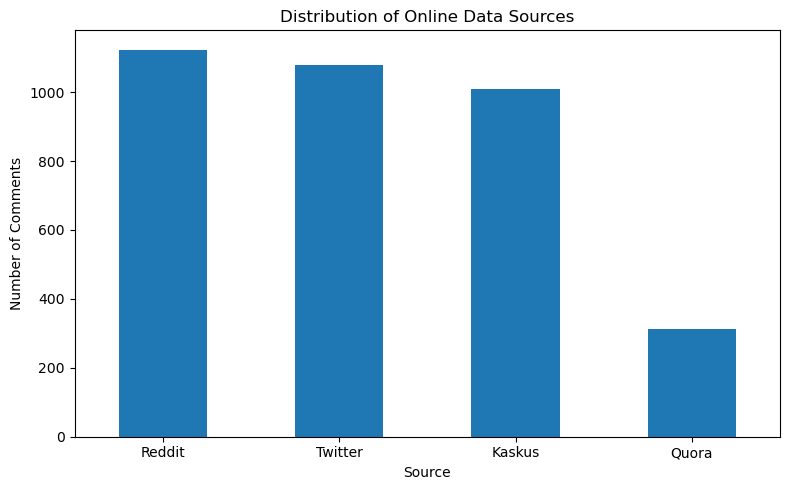

In [9]:
print("SOURCE DISTRIBUTION")
print("=" * 40)

source_counts = df["source"].value_counts()

print(source_counts)
print("\nPercentage:")
print((df["source"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(8, 5))

df["source"].value_counts().plot(kind="bar")

plt.title("Distribution of Online Data Sources")
plt.xlabel("Source")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

LANGUAGE DISTRIBUTION
language
ID    2311
US    1212
Name: count, dtype: int64

Percentage:
language
ID    65.6
US    34.4
Name: proportion, dtype: float64


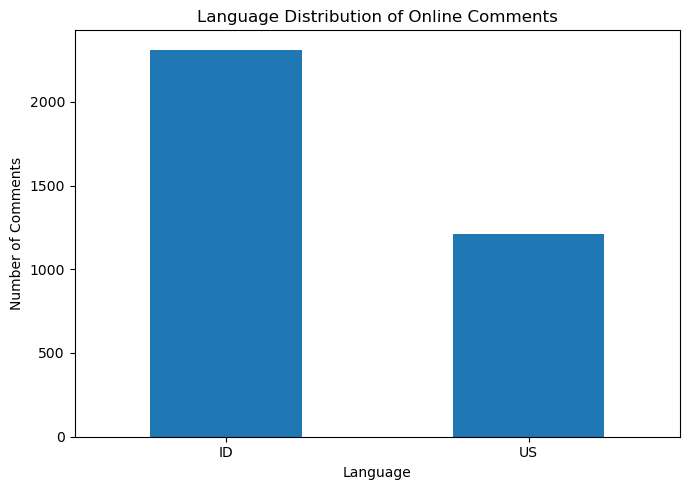

In [12]:
print("LANGUAGE DISTRIBUTION")
print("=" * 40)

language_counts = df["language"].value_counts()

print(language_counts)
print("\nPercentage:")
print((df["language"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(7, 5))

df["language"].value_counts().plot(kind="bar")

plt.title("Language Distribution of Online Comments")
plt.xlabel("Language")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

SENTIMENT DISTRIBUTION
sentiment
positif    1741
netral      905
negatif     877
Name: count, dtype: int64

Percentage:
sentiment
positif    49.42
netral     25.69
negatif    24.89
Name: proportion, dtype: float64


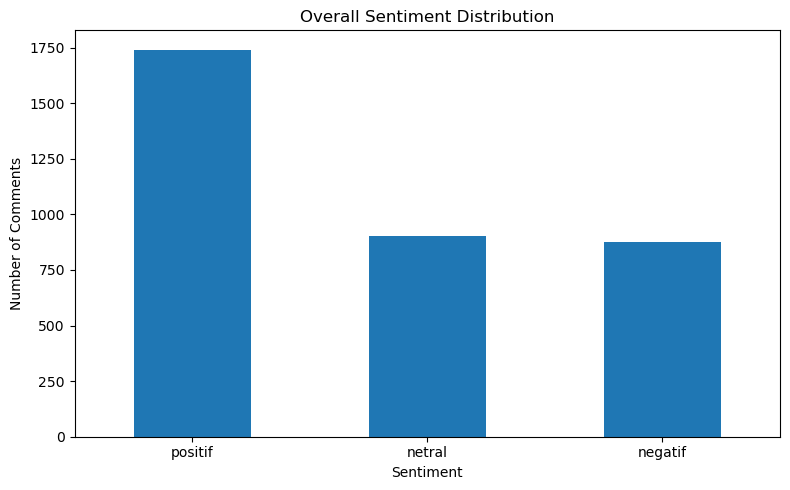

In [10]:
print("SENTIMENT DISTRIBUTION")
print("=" * 40)

sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)
print("\nPercentage:")
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(8, 5))

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

TOPIC DISTRIBUTION
topic
Eco-Friendly Products          913
Biodegradable                  625
Green Energy                   499
Circular Economy               347
Thrift Business                228
Reusable Containers            222
Eco-Friendly Business Ideas    220
Less Sustainable Product       219
Eco-Friendly Brand             131
Recycling Business              62
Sustainable Products Price      57
Name: count, dtype: int64


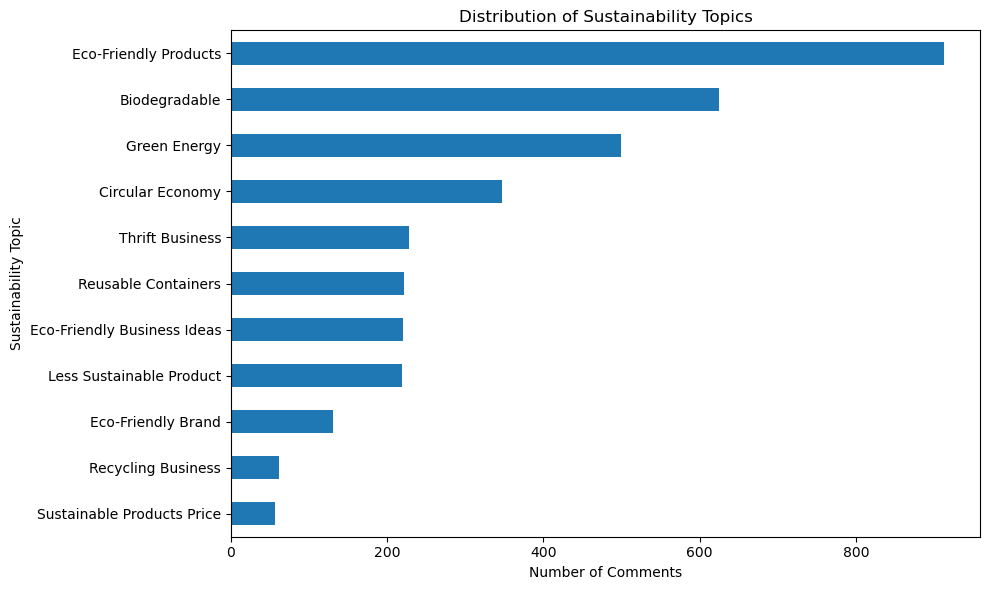

In [11]:
print("TOPIC DISTRIBUTION")
print("=" * 50)

topic_counts = df["topic"].value_counts()

print(topic_counts)

plt.figure(figsize=(10, 6))

df["topic"].value_counts().sort_values().plot(kind="barh")

plt.title("Distribution of Sustainability Topics")
plt.xlabel("Number of Comments")
plt.ylabel("Sustainability Topic")

plt.tight_layout()
plt.show()

### 5. Filtering the English Dataset:

In [13]:
df_english = df[df["language"] == "US"].copy()

print("Original dataset size:", df.shape)
print("English dataset size:", df_english.shape)

print("\nEnglish Sentiment Distribution:")
print(df_english["sentiment"].value_counts())

print("\nEnglish Source Distribution:")
print(df_english["source"].value_counts())

print("\nEnglish Topic Distribution:")
print(df_english["topic"].value_counts())

Original dataset size: (3523, 6)
English dataset size: (1212, 6)

English Sentiment Distribution:
sentiment
negatif    508
positif    357
netral     347
Name: count, dtype: int64

English Source Distribution:
source
Reddit    1123
Quora       89
Name: count, dtype: int64

English Topic Distribution:
topic
Circular Economy              347
Eco-Friendly Products         235
Reusable Containers           222
Less Sustainable Product      215
Eco-Friendly Brand             67
Sustainable Products Price     57
Biodegradable                  27
Thrift Business                24
Recycling Business             18
Name: count, dtype: int64


### 6. Converting sentiment labels to English:

In [14]:
sentiment_mapping = {
    "positif": "Positive",
    "netral": "Neutral",
    "negatif": "Negative"
}

df_english["sentiment_label"] = df_english["sentiment"].map(sentiment_mapping)

print(df_english["sentiment_label"].value_counts())

sentiment_label
Negative    508
Positive    357
Neutral     347
Name: count, dtype: int64


In [15]:
df_english[
    ["comment", "sentiment", "sentiment_label"]
].head(10)

,comment,sentiment,sentiment_label
1001,Something that has been bothering me is it see...,negatif,Negative
1002,I would say a convenience product with reusabl...,negatif,Negative
1003,I think that every small community should have...,positif,Positive
1004,I would love a wallet case for my phone.,negatif,Negative
1005,"I travelled in a van for a year, during the su...",negatif,Negative
1006,"Not really a product, but I wish more companie...",netral,Neutral
1007,Another thing-- I wish more mainstream compani...,netral,Neutral
1008,Someone please make hemp dental floss! Compost...,netral,Neutral
1009,basket weaving,netral,Neutral
1010,I don’t know if this counts but I desperately ...,netral,Neutral


### 7. Checking Duplicates before Cleaning

In [16]:
print("Records before duplicate removal:", len(df_english))

print(
    "Duplicate comments:",
    df_english["comment"].duplicated().sum()
)

Records before duplicate removal: 1212
Duplicate comments: 14


### 8. Text Preprocessing:

In [17]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /Users/admin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/admin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/admin/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [19]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [20]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [21]:
df_english["clean_comment"] = df_english["comment"].apply(clean_text)

In [22]:
df_english[
    ["comment","clean_comment"]
].head(10)

,comment,clean_comment
1001,Something that has been bothering me is it see...,something bothering seems like shower curtain ...
1002,I would say a convenience product with reusabl...,would say convenience product reusable packagi...
1003,I think that every small community should have...,think every small community shared tool shed l...
1004,I would love a wallet case for my phone.,would love wallet case phone
1005,"I travelled in a van for a year, during the su...",travelled van year summer needed buy ice every...
1006,"Not really a product, but I wish more companie...",really product wish company would take back ol...
1007,Another thing-- I wish more mainstream compani...,another thing wish mainstream company would of...
1008,Someone please make hemp dental floss! Compost...,someone please make hemp dental floss composta...
1009,basket weaving,basket weaving
1010,I don’t know if this counts but I desperately ...,’ know count desperately want electronicsappli...


In [24]:
print("Empty cleaned comments:")

print((df_english["clean_comment"]=="").sum())

Empty cleaned comments:
2


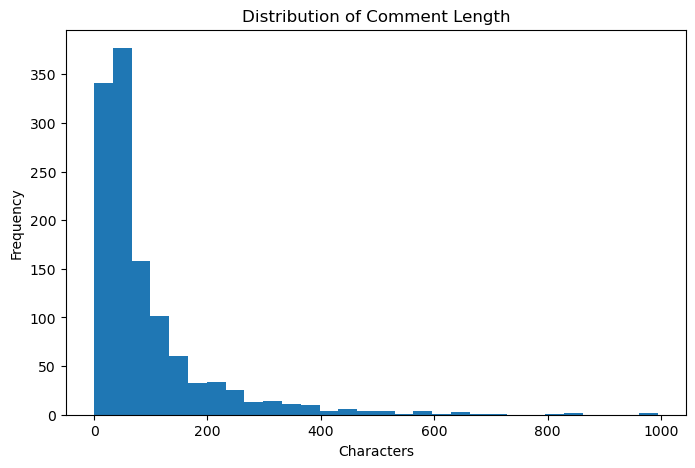

In [25]:
df_english["comment_length"] = df_english["clean_comment"].apply(len)

plt.figure(figsize=(8,5))

plt.hist(df_english["comment_length"], bins=30)

plt.title("Distribution of Comment Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

### 9. Final Data cleaning:

In [26]:
# Removing duplicate comments
df_english = df_english.drop_duplicates(subset="clean_comment")

# Removing empty cleaned comments
df_english = df_english[df_english["clean_comment"] != ""]

# Reset index
df_english.reset_index(drop=True, inplace=True)

print("Final dataset shape:", df_english.shape)

print("\nSentiment Distribution:")
print(df_english["sentiment_label"].value_counts())

Final dataset shape: (1180, 9)

Sentiment Distribution:
sentiment_label
Negative    496
Positive    346
Neutral     338
Name: count, dtype: int64


### 10. Preparing Features and Target:

In [27]:
X = df_english["clean_comment"]

y = df_english["sentiment_label"]

print("Feature size:", len(X))
print("Target size:", len(y))

Feature size: 1180
Target size: 1180


### 11. Train Test Split - 80:20

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

Training samples : 944
Testing samples  : 236


### 12. TF-IDF Vectorization

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training Matrix Shape:", X_train_tfidf.shape)
print("Testing Matrix Shape :", X_test_tfidf.shape)

Training Matrix Shape: (944, 1910)
Testing Matrix Shape : (236, 1910)


### 13. Viewing Top Features:

In [30]:
feature_names = tfidf.get_feature_names_out()

print("Total Features:", len(feature_names))

print("\nFirst 50 Features:")

print(feature_names[:50])

Total Features: 1910

First 50 Features:
['able' 'absolute' 'absolutely' 'access' 'accessible' 'according'
 'account' 'accumulating' 'acknowledge' 'acre' 'across' 'action' 'actual'
 'actually' 'actually recycle' 'ad' 'add' 'adding' 'advancement' 'advice'
 'afaik' 'afford' 'affordable' 'afterwards' 'ago' 'agree'
 'agree principle' 'agreed' 'agriculture' 'ah' 'ah yes' 'aim' 'air'
 'algae' 'almost' 'alone' 'already' 'already happening' 'also' 'also need'
 'also recycling' 'also searching' 'alternative' 'always' 'always mean'
 'always use' 'always wondered' 'amazing' 'amazon' 'america']


### 14. Logistic Regression Model:

In [35]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


### 15. Logistic Regression Evaluation:

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, lr_predictions))

print("Precision:",
      precision_score(
          y_test,
          lr_predictions,
          average="weighted"
      ))

print("Recall   :",
      recall_score(
          y_test,
          lr_predictions,
          average="weighted"
      ))

print("F1 Score :",
      f1_score(
          y_test,
          lr_predictions,
          average="weighted"
      ))

print("\nClassification Report")

print(classification_report(y_test, lr_predictions))

Accuracy : 0.5127118644067796
Precision: 0.5182099606672314
Recall   : 0.5127118644067796
F1 Score : 0.5059366907526052

Classification Report
              precision    recall  f1-score   support

    Negative       0.50      0.66      0.57        99
     Neutral       0.57      0.40      0.47        68
    Positive       0.48      0.42      0.45        69

    accuracy                           0.51       236
   macro avg       0.52      0.49      0.50       236
weighted avg       0.52      0.51      0.51       236



### 16. Logistic Regression Confusion Matrix

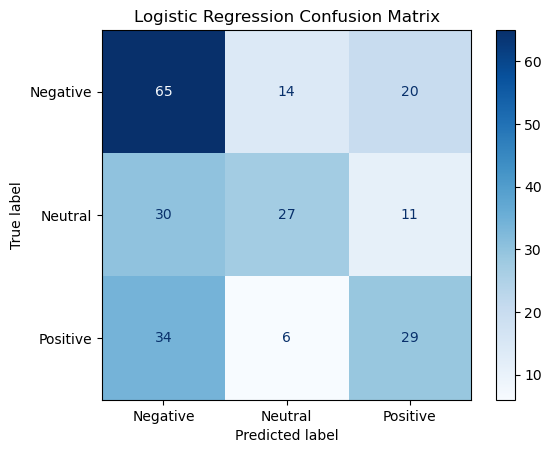

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

### 17. Multinomial Naïve Bayes Model:

In [37]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Naïve Bayes Model Trained Successfully!")

Naïve Bayes Model Trained Successfully!


### 18. Multinomial Naïve Bayes Model Evaluation:

In [38]:
print("Accuracy :", accuracy_score(y_test, nb_predictions))

print("Precision:",
      precision_score(y_test, nb_predictions,
                      average="weighted"))

print("Recall:",
      recall_score(y_test, nb_predictions,
                   average="weighted"))

print("F1 Score:",
      f1_score(y_test, nb_predictions,
               average="weighted"))

print(classification_report(y_test, nb_predictions))

Accuracy : 0.5423728813559322
Precision: 0.5701763396678652
Recall: 0.5423728813559322
F1 Score: 0.5130723583454888
              precision    recall  f1-score   support

    Negative       0.51      0.84      0.64        99
     Neutral       0.63      0.28      0.39        68
    Positive       0.59      0.38      0.46        69

    accuracy                           0.54       236
   macro avg       0.58      0.50      0.49       236
weighted avg       0.57      0.54      0.51       236



### 19. Multinomial Naïve Bayes Model Confusion Matrix:

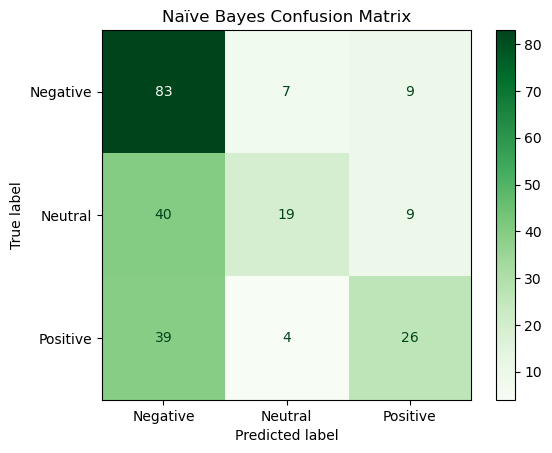

In [39]:
ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test_tfidf,
    y_test,
    cmap="Greens"
)

plt.title("Naïve Bayes Confusion Matrix")

plt.show()

### 20. Linear Support Vector Machine (SVM) Model: 

In [40]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)

print("Linear SVM Model Trained Successfully!")

Linear SVM Model Trained Successfully!


### 21. Linear SVM Evaluation:

In [41]:
print("Accuracy :", accuracy_score(y_test, svm_predictions))

print("Precision:",
      precision_score(y_test, svm_predictions,
                      average="weighted"))

print("Recall:",
      recall_score(y_test, svm_predictions,
                   average="weighted"))

print("F1 Score:",
      f1_score(y_test, svm_predictions,
               average="weighted"))

print(classification_report(y_test, svm_predictions))

Accuracy : 0.5
Precision: 0.49754478263010876
Recall: 0.5
F1 Score: 0.4968354772185666
              precision    recall  f1-score   support

    Negative       0.55      0.60      0.57        99
     Neutral       0.47      0.38      0.42        68
    Positive       0.45      0.48      0.46        69

    accuracy                           0.50       236
   macro avg       0.49      0.49      0.49       236
weighted avg       0.50      0.50      0.50       236



### 22. Linear SVM Confusion Matrix:

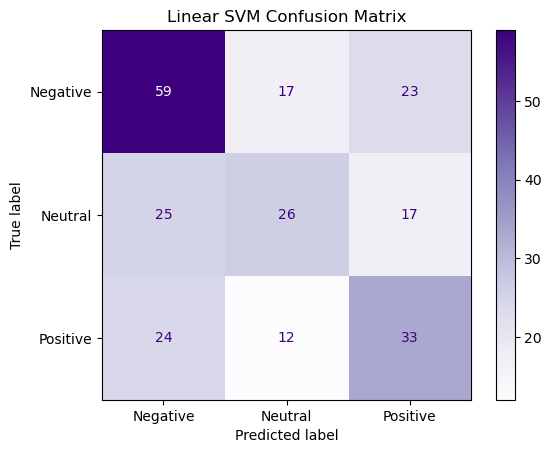

In [42]:
ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test_tfidf,
    y_test,
    cmap="Purples"
)

plt.title("Linear SVM Confusion Matrix")

plt.show()

### 23. All Models Comparision:

In [49]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, svm_predictions)
    ],

    "Precision": [
        precision_score(y_test, lr_predictions, average="weighted"),
        precision_score(y_test, nb_predictions, average="weighted"),
        precision_score(y_test, svm_predictions, average="weighted")
    ],

    "Recall": [
        recall_score(y_test, lr_predictions, average="weighted"),
        recall_score(y_test, nb_predictions, average="weighted"),
        recall_score(y_test, svm_predictions, average="weighted")
    ],

    "F1 Score": [
        f1_score(y_test, lr_predictions, average="weighted"),
        f1_score(y_test, nb_predictions, average="weighted"),
        f1_score(y_test, svm_predictions, average="weighted")
    ]
})

comparison = comparison.round(3)

print("Machine Learning Model Performance Comparison")
display(comparison)

Machine Learning Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.513,0.518,0.513,0.506
1,Multinomial Naive Bayes,0.542,0.570,0.542,0.513
2,Linear SVM,0.500,0.498,0.500,0.497


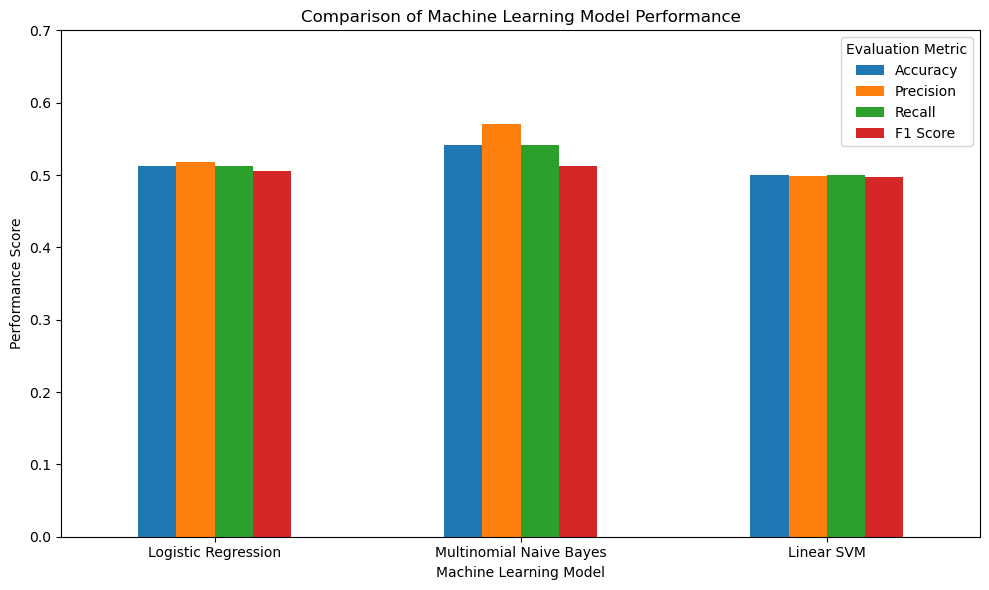

In [50]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Machine Learning Model Performance")
plt.xlabel("Machine Learning Model")
plt.ylabel("Performance Score")

plt.ylim(0, 0.7)

plt.xticks(rotation=0)

plt.legend(
    title="Evaluation Metric",
    loc="upper right"
)

plt.tight_layout()
plt.show()

### 24. Hyperparameter Tuning for all 3 Models:

### A. Multinomial Naive Bayes: 

In [64]:
from sklearn.model_selection import GridSearchCV

nb_param_grid = {
    "alpha": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
    "fit_prior": [True, False]
}

nb_grid = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=nb_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

nb_grid.fit(X_train_tfidf, y_train)

print("Best Parameters:")
print(nb_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(nb_grid.best_score_, 4))

Best Parameters:
{'alpha': 5.0, 'fit_prior': False}

Best Cross-Validation F1 Score:
0.5709


In [65]:
# EVALUATION OF TUNED NAIVE BAYES MODEL

tuned_nb_model = nb_grid.best_estimator_

tuned_nb_predictions = tuned_nb_model.predict(X_test_tfidf)

tuned_nb_accuracy = accuracy_score(y_test, tuned_nb_predictions)

tuned_nb_precision = precision_score(
    y_test,
    tuned_nb_predictions,
    average="weighted"
)

tuned_nb_recall = recall_score(
    y_test,
    tuned_nb_predictions,
    average="weighted"
)

tuned_nb_f1 = f1_score(
    y_test,
    tuned_nb_predictions,
    average="weighted"
)

print("Tuned Naive Bayes Performance")
print("=" * 40)

print("Accuracy :", round(tuned_nb_accuracy, 4))
print("Precision:", round(tuned_nb_precision, 4))
print("Recall   :", round(tuned_nb_recall, 4))
print("F1 Score :", round(tuned_nb_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, tuned_nb_predictions))

Tuned Naive Bayes Performance
Accuracy : 0.5381
Precision: 0.5394
Recall   : 0.5381
F1 Score : 0.5323

Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.64      0.60        99
     Neutral       0.54      0.37      0.44        68
    Positive       0.49      0.57      0.52        69

    accuracy                           0.54       236
   macro avg       0.53      0.52      0.52       236
weighted avg       0.54      0.54      0.53       236



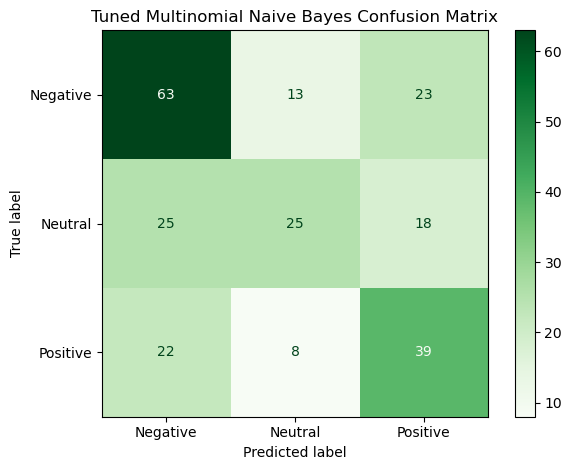

In [66]:
# TUNED NAIVE BAYES CONFUSION MATRIX

ConfusionMatrixDisplay.from_estimator(
    tuned_nb_model,
    X_test_tfidf,
    y_test,
    cmap="Greens"
)

plt.title("Tuned Multinomial Naive Bayes Confusion Matrix")

plt.tight_layout()
plt.show()

### B. Logistic Regression:

In [67]:
lr_param_grid = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=lr_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train_tfidf, y_train)

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(lr_grid.best_score_, 4))

Best Logistic Regression Parameters:
{'C': 1, 'class_weight': 'balanced'}

Best Cross-Validation F1 Score:
0.5597


In [68]:
# EVALUATION TUNED LOGISTIC REGRESSION

tuned_lr_model = lr_grid.best_estimator_

tuned_lr_predictions = tuned_lr_model.predict(X_test_tfidf)

print("Tuned Logistic Regression")

print("Accuracy:",
      round(
          accuracy_score(
              y_test,
              tuned_lr_predictions
          ), 4
      ))

print("Precision:",
      round(
          precision_score(
              y_test,
              tuned_lr_predictions,
              average="weighted"
          ), 4
      ))

print("Recall:",
      round(
          recall_score(
              y_test,
              tuned_lr_predictions,
              average="weighted"
          ), 4
      ))

print("F1 Score:",
      round(
          f1_score(
              y_test,
              tuned_lr_predictions,
              average="weighted"
          ), 4
      ))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tuned_lr_predictions
    )
)

Tuned Logistic Regression
Accuracy: 0.4915
Precision: 0.4971
Recall: 0.4915
F1 Score: 0.4926

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.48      0.52        99
     Neutral       0.44      0.47      0.46        68
    Positive       0.46      0.52      0.49        69

    accuracy                           0.49       236
   macro avg       0.49      0.49      0.49       236
weighted avg       0.50      0.49      0.49       236



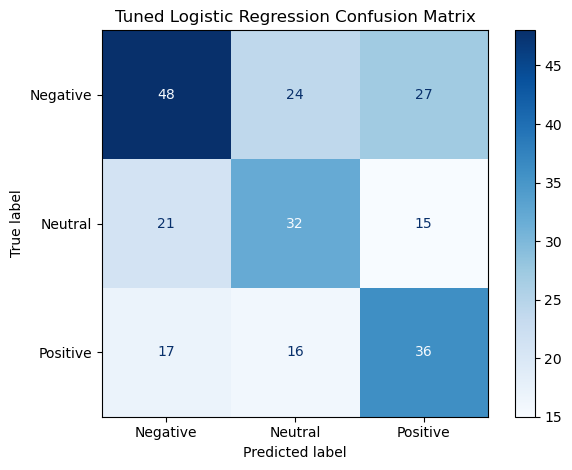

In [69]:
# TUNED LOGISTIC REGRESSION CONFUSION MATRIX

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    tuned_lr_model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.title("Tuned Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

### C. Linear SVM: 

In [70]:
svm_param_grid = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

svm_grid = GridSearchCV(
    estimator=LinearSVC(
        random_state=42
    ),
    param_grid=svm_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train_tfidf, y_train)

print("Best Linear SVM Parameters:")
print(svm_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(svm_grid.best_score_, 4))

Best Linear SVM Parameters:
{'C': 0.1, 'class_weight': 'balanced'}

Best Cross-Validation F1 Score:
0.5563


In [71]:
# EVALUATION TUNED LINEAR SVM

tuned_svm_model = svm_grid.best_estimator_

tuned_svm_predictions = tuned_svm_model.predict(X_test_tfidf)

print("Tuned Linear SVM")

print("Accuracy:",
      round(
          accuracy_score(
              y_test,
              tuned_svm_predictions
          ), 4
      ))

print("Precision:",
      round(
          precision_score(
              y_test,
              tuned_svm_predictions,
              average="weighted"
          ), 4
      ))

print("Recall:",
      round(
          recall_score(
              y_test,
              tuned_svm_predictions,
              average="weighted"
          ), 4
      ))

print("F1 Score:",
      round(
          f1_score(
              y_test,
              tuned_svm_predictions,
              average="weighted"
          ), 4
      ))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tuned_svm_predictions
    )
)

Tuned Linear SVM
Accuracy: 0.4958
Precision: 0.4944
Recall: 0.4958
F1 Score: 0.4941

Classification Report:
              precision    recall  f1-score   support

    Negative       0.51      0.56      0.53        99
     Neutral       0.47      0.41      0.44        68
    Positive       0.49      0.49      0.49        69

    accuracy                           0.50       236
   macro avg       0.49      0.49      0.49       236
weighted avg       0.49      0.50      0.49       236



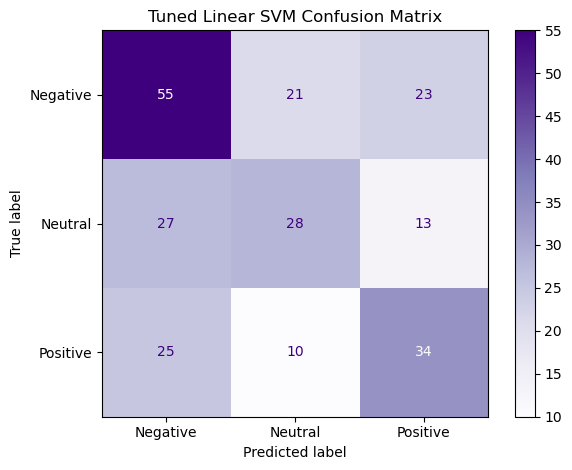

In [72]:
# TUNED LINEAR SVM CONFUSION MATRIX

ConfusionMatrixDisplay.from_estimator(
    tuned_svm_model,
    X_test_tfidf,
    y_test,
    cmap="Purples"
)

plt.title("Tuned Linear SVM Confusion Matrix")
plt.tight_layout()
plt.show()

### All Models Tuned Comparision:

In [75]:
tuned_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, tuned_lr_predictions),
        accuracy_score(y_test, tuned_nb_predictions),
        accuracy_score(y_test, tuned_svm_predictions)
    ],

    "Precision": [
        precision_score(y_test, tuned_lr_predictions, average="weighted"),
        precision_score(y_test, tuned_nb_predictions, average="weighted"),
        precision_score(y_test, tuned_svm_predictions, average="weighted")
    ],

    "Recall": [
        recall_score(y_test, tuned_lr_predictions, average="weighted"),
        recall_score(y_test, tuned_nb_predictions, average="weighted"),
        recall_score(y_test, tuned_svm_predictions, average="weighted")
    ],

    "F1 Score": [
        f1_score(y_test, tuned_lr_predictions, average="weighted"),
        f1_score(y_test, tuned_nb_predictions, average="weighted"),
        f1_score(y_test, tuned_svm_predictions, average="weighted")
    ]

})

tuned_comparison = tuned_comparison.round(3)

print("Performance Comparison of Tuned Machine Learning Models")
display(tuned_comparison)

Performance Comparison of Tuned Machine Learning Models


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.492,0.497,0.492,0.493
1,Multinomial Naive Bayes,0.538,0.539,0.538,0.532
2,Linear SVM,0.496,0.494,0.496,0.494


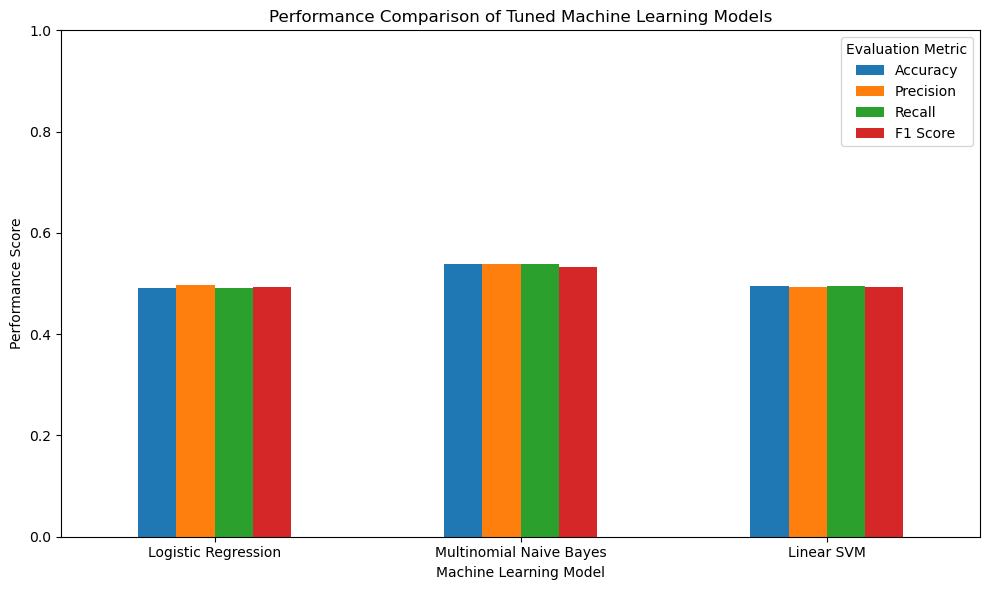

In [76]:
tuned_plot = tuned_comparison.set_index("Model")

tuned_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Tuned Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Performance Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Evaluation Metric",
    loc="upper right"
)

plt.tight_layout()
plt.show()

### 25. Comparision of Models Before vs After Tuning:

In [73]:
before_after = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],

    "Accuracy Before": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, svm_predictions)
    ],

    "Accuracy After": [
        accuracy_score(y_test, tuned_lr_predictions),
        accuracy_score(y_test, tuned_nb_predictions),
        accuracy_score(y_test, tuned_svm_predictions)
    ],

    "Precision Before": [
        precision_score(y_test, lr_predictions, average="weighted"),
        precision_score(y_test, nb_predictions, average="weighted"),
        precision_score(y_test, svm_predictions, average="weighted")
    ],

    "Precision After": [
        precision_score(y_test, tuned_lr_predictions, average="weighted"),
        precision_score(y_test, tuned_nb_predictions, average="weighted"),
        precision_score(y_test, tuned_svm_predictions, average="weighted")
    ],

    "Recall Before": [
        recall_score(y_test, lr_predictions, average="weighted"),
        recall_score(y_test, nb_predictions, average="weighted"),
        recall_score(y_test, svm_predictions, average="weighted")
    ],

    "Recall After": [
        recall_score(y_test, tuned_lr_predictions, average="weighted"),
        recall_score(y_test, tuned_nb_predictions, average="weighted"),
        recall_score(y_test, tuned_svm_predictions, average="weighted")
    ],

    "F1 Before": [
        f1_score(y_test, lr_predictions, average="weighted"),
        f1_score(y_test, nb_predictions, average="weighted"),
        f1_score(y_test, svm_predictions, average="weighted")
    ],

    "F1 After": [
        f1_score(y_test, tuned_lr_predictions, average="weighted"),
        f1_score(y_test, tuned_nb_predictions, average="weighted"),
        f1_score(y_test, tuned_svm_predictions, average="weighted")
    ]

})

before_after = before_after.round(3)

print("Comparison of Machine Learning Models Before and After Hyperparameter Tuning")

display(before_after)

Comparison of Machine Learning Models Before and After Hyperparameter Tuning


,Model,Accuracy Before,Accuracy After,Precision Before,Precision After,Recall Before,Recall After,F1 Before,F1 After
0,Logistic Regression,0.513,0.492,0.518,0.497,0.513,0.492,0.506,0.493
1,Multinomial Naive Bayes,0.542,0.538,0.570,0.539,0.542,0.538,0.513,0.532
2,Linear SVM,0.500,0.496,0.498,0.494,0.500,0.496,0.497,0.494


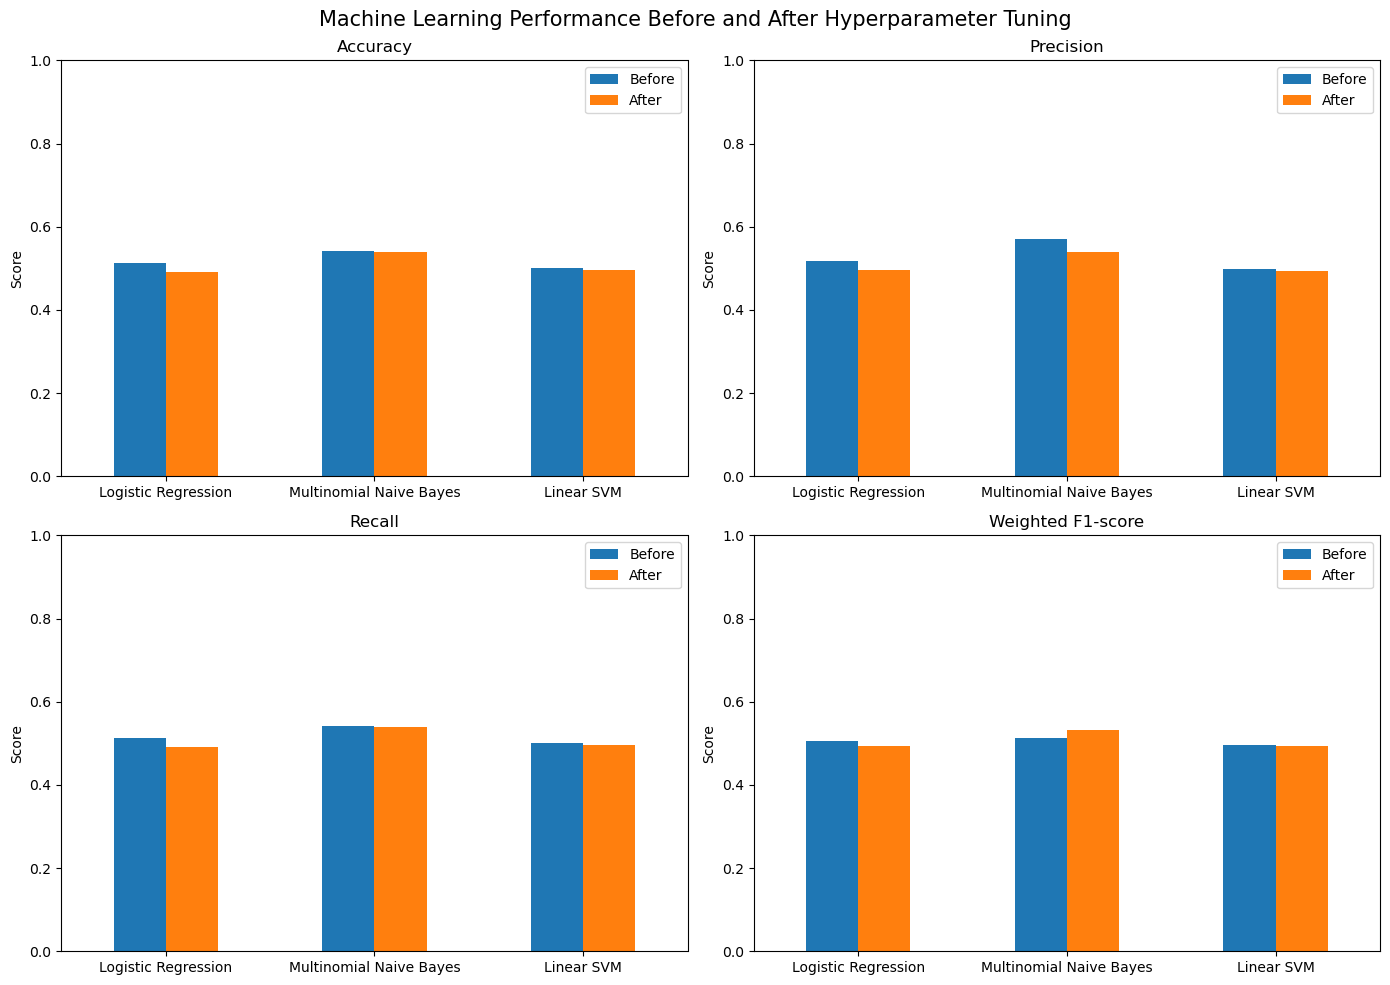

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

metrics = [
    ("Accuracy Before","Accuracy After","Accuracy"),
    ("Precision Before","Precision After","Precision"),
    ("Recall Before","Recall After","Recall"),
    ("F1 Before","F1 After","Weighted F1-score")
]

for ax, (before, after, title) in zip(axes.flatten(), metrics):

    plot_df = before_after.set_index("Model")[[before, after]]

    plot_df.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(title)

    ax.set_xlabel("")

    ax.set_ylabel("Score")

    ax.set_ylim(0,1)

    ax.tick_params(axis='x', rotation=0)

    ax.legend(["Before","After"])

plt.suptitle(
    "Machine Learning Performance Before and After Hyperparameter Tuning",
    fontsize=15
)

plt.tight_layout()

plt.show()

### 26. VADER Sentiment Analysis:

In [77]:
import nltk

nltk.download("vader_lexicon")

from nltk.sentiment.vader import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

print("VADER sentiment analyser loaded successfully.")

VADER sentiment analyser loaded successfully.


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/admin/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


### 27. Generating VADER sentiment scores:

In [79]:
# Applying VADER to the ORIGINAL English comments

df_english["vader_compound"] = df_english["comment"].apply(
    lambda text: vader.polarity_scores(str(text))["compound"]
)

df_english["vader_positive"] = df_english["comment"].apply(
    lambda text: vader.polarity_scores(str(text))["pos"]
)

df_english["vader_neutral"] = df_english["comment"].apply(
    lambda text: vader.polarity_scores(str(text))["neu"]
)

df_english["vader_negative"] = df_english["comment"].apply(
    lambda text: vader.polarity_scores(str(text))["neg"]
)

df_english[
    [
        "comment",
        "sentiment_label",
        "vader_positive",
        "vader_neutral",
        "vader_negative",
        "vader_compound"
    ]
].head(10)

,comment,sentiment_label,vader_positive,vader_neutral,vader_negative,vader_compound
0,Something that has been bothering me is it see...,Negative,0.057,0.884,0.059,-0.0258
1,I would say a convenience product with reusabl...,Negative,0.099,0.857,0.044,0.8941
2,I think that every small community should have...,Positive,0.146,0.854,0.000,0.6666
3,I would love a wallet case for my phone.,Negative,0.412,0.588,0.000,0.6369
4,"I travelled in a van for a year, during the su...",Negative,0.048,0.952,0.000,0.3182
5,"Not really a product, but I wish more companie...",Neutral,0.158,0.842,0.000,0.6054
6,Another thing-- I wish more mainstream compani...,Neutral,0.231,0.769,0.000,0.4019
7,Someone please make hemp dental floss! Compost...,Neutral,0.420,0.580,0.000,0.6996
8,basket weaving,Neutral,0.000,1.000,0.000,0.0000
9,I don’t know if this counts but I desperately ...,Neutral,0.086,0.712,0.202,-0.4497


### 28. Converting VADER scores into sentiment classes:

In [80]:
def classify_vader(compound_score):
    
    if compound_score >= 0.05:
        return "Positive"
    
    elif compound_score <= -0.05:
        return "Negative"
    
    else:
        return "Neutral"


df_english["vader_sentiment"] = df_english[
    "vader_compound"
].apply(classify_vader)

print("VADER Sentiment Distribution")
print("=" * 40)

print(df_english["vader_sentiment"].value_counts())

print("\nPercentage Distribution")

print(
    (
        df_english["vader_sentiment"]
        .value_counts(normalize=True) * 100
    ).round(2)
)

VADER Sentiment Distribution
vader_sentiment
Positive    501
Neutral     361
Negative    318
Name: count, dtype: int64

Percentage Distribution
vader_sentiment
Positive    42.46
Neutral     30.59
Negative    26.95
Name: proportion, dtype: float64


### 29. Visualising VADER sentiment distribution:

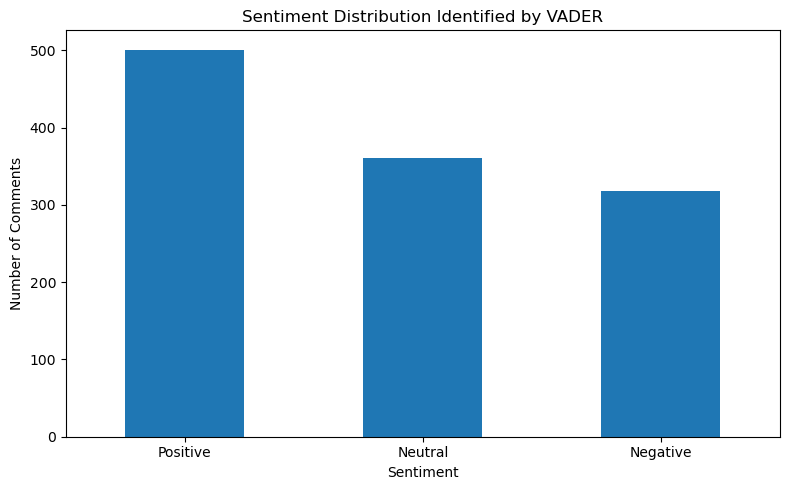

In [83]:
vader_counts = (
    df_english["vader_sentiment"]
    .value_counts()
    .reindex(["Positive", "Neutral", "Negative"])
)

plt.figure(figsize=(8, 5))

vader_counts.plot(kind="bar")

plt.title("Sentiment Distribution Identified by VADER")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 30. Comparing VADER with the dataset labels:

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

vader_accuracy = accuracy_score(
    df_english["sentiment_label"],
    df_english["vader_sentiment"]
)

vader_precision = precision_score(
    df_english["sentiment_label"],
    df_english["vader_sentiment"],
    average="weighted",
    zero_division=0
)

vader_recall = recall_score(
    df_english["sentiment_label"],
    df_english["vader_sentiment"],
    average="weighted",
    zero_division=0
)

vader_f1 = f1_score(
    df_english["sentiment_label"],
    df_english["vader_sentiment"],
    average="weighted",
    zero_division=0
)

print("VADER PERFORMANCE")
print("=" * 40)

print("Accuracy :", round(vader_accuracy, 4))
print("Precision:", round(vader_precision, 4))
print("Recall   :", round(vader_recall, 4))
print("F1 Score :", round(vader_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        df_english["sentiment_label"],
        df_english["vader_sentiment"],
        zero_division=0
    )
)

VADER PERFORMANCE
Accuracy : 0.4559
Precision: 0.4846
Recall   : 0.4559
F1 Score : 0.4558

Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.38      0.46       496
     Neutral       0.43      0.46      0.45       338
    Positive       0.39      0.56      0.46       346

    accuracy                           0.46      1180
   macro avg       0.47      0.47      0.46      1180
weighted avg       0.48      0.46      0.46      1180



### 31. VADER Confusion Matrix:

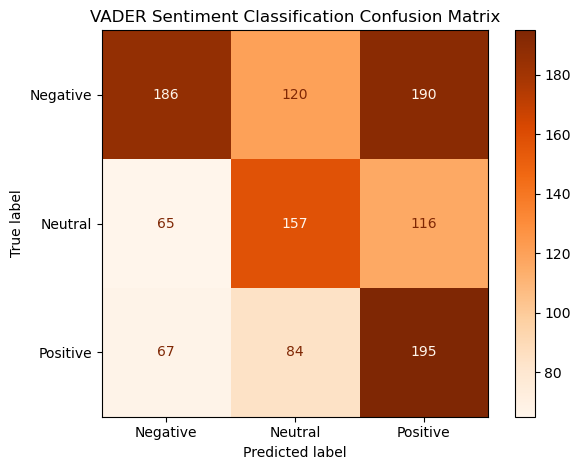

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    df_english["sentiment_label"],
    df_english["vader_sentiment"],
    labels=["Negative", "Neutral", "Positive"],
    cmap="Oranges"
)

plt.title("VADER Sentiment Classification Confusion Matrix")

plt.tight_layout()
plt.show()

### 32. Topic-wise Sentiment Analysis:

In [86]:
topic_sentiment_counts = pd.crosstab(
    df_english["topic"],
    df_english["sentiment_label"]
)

print("Topic-wise Sentiment Counts")
display(topic_sentiment_counts)

Topic-wise Sentiment Counts


sentiment_label,Negative,Neutral,Positive
topic,,,
Biodegradable,10,17,0
Circular Economy,132,109,97
Eco-Friendly Brand,4,26,37
Eco-Friendly Products,85,65,81
Less Sustainable Product,55,42,104
Recycling Business,0,18,0
Reusable Containers,175,30,12
Sustainable Products Price,25,18,14
Thrift Business,10,13,1


In [87]:
# TOPIC-WISE SENTIMENT PERCENTAGES

topic_sentiment_pct = pd.crosstab(
    df_english["topic"],
    df_english["sentiment_label"],
    normalize="index"
) * 100

topic_sentiment_pct = topic_sentiment_pct.round(2)

print("Topic-wise Sentiment Percentage Distribution")
display(topic_sentiment_pct)

Topic-wise Sentiment Percentage Distribution


sentiment_label,Negative,Neutral,Positive
topic,,,
Biodegradable,37.04,62.96,0.00
Circular Economy,39.05,32.25,28.70
Eco-Friendly Brand,5.97,38.81,55.22
Eco-Friendly Products,36.80,28.14,35.06
Less Sustainable Product,27.36,20.90,51.74
Recycling Business,0.00,100.00,0.00
Reusable Containers,80.65,13.82,5.53
Sustainable Products Price,43.86,31.58,24.56
Thrift Business,41.67,54.17,4.17


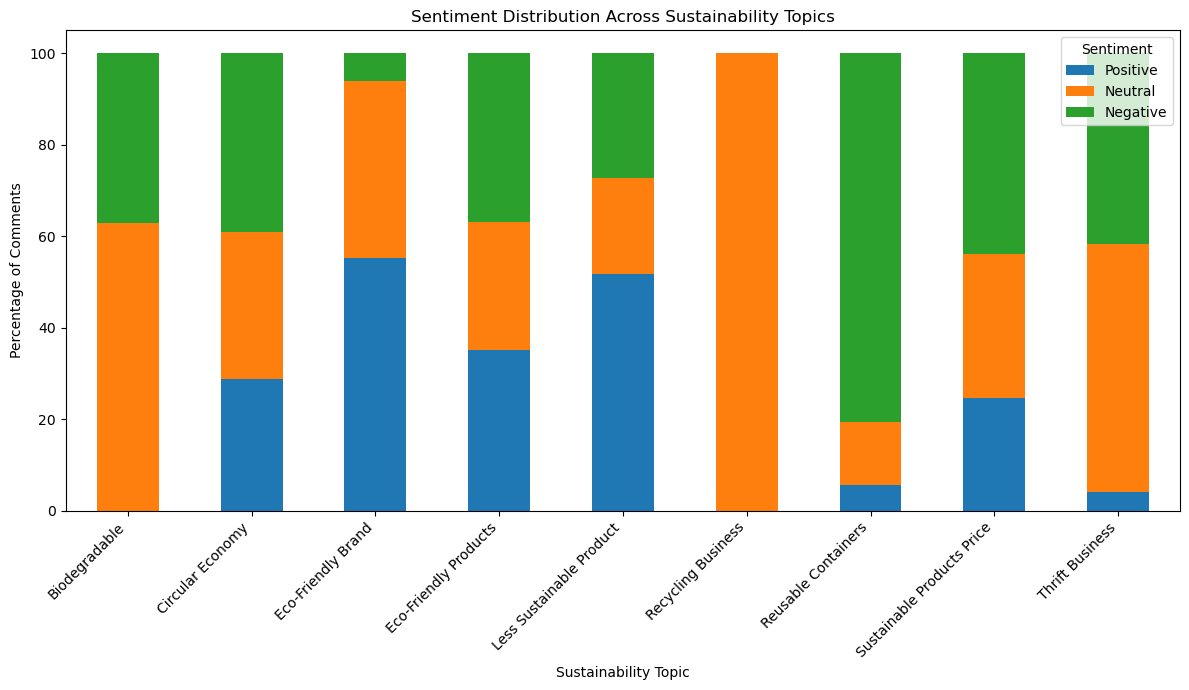

In [88]:
topic_sentiment_pct[
    ["Positive", "Neutral", "Negative"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Sentiment Distribution Across Sustainability Topics")
plt.xlabel("Sustainability Topic")
plt.ylabel("Percentage of Comments")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

### 33. Identifying strongest positive and negative topics:

In [89]:
# MOST POSITIVE AND MOST NEGATIVE TOPICS

most_positive_topic = topic_sentiment_pct["Positive"].idxmax()
most_positive_value = topic_sentiment_pct["Positive"].max()

most_negative_topic = topic_sentiment_pct["Negative"].idxmax()
most_negative_value = topic_sentiment_pct["Negative"].max()

print("Most Positive Sustainability Topic:")
print(most_positive_topic, "-", most_positive_value, "%")

print("\nMost Negative Sustainability Topic:")
print(most_negative_topic, "-", most_negative_value, "%")

Most Positive Sustainability Topic:
Eco-Friendly Brand - 55.22 %

Most Negative Sustainability Topic:
Reusable Containers - 80.65 %


### 34. Ranking all topics by positivity and negativity:

In [90]:
positive_ranking = (
    topic_sentiment_pct["Positive"]
    .sort_values(ascending=False)
    .reset_index()
)

positive_ranking.columns = [
    "Topic",
    "Positive Sentiment (%)"
]

negative_ranking = (
    topic_sentiment_pct["Negative"]
    .sort_values(ascending=False)
    .reset_index()
)

negative_ranking.columns = [
    "Topic",
    "Negative Sentiment (%)"
]

print("Topics Ranked by Positive Sentiment")
display(positive_ranking)

print("\nTopics Ranked by Negative Sentiment")
display(negative_ranking)

Topics Ranked by Positive Sentiment


,Topic,Positive Sentiment (%)
0,Eco-Friendly Brand,55.22
1,Less Sustainable Product,51.74
2,Eco-Friendly Products,35.06
3,Circular Economy,28.70
4,Sustainable Products Price,24.56
5,Reusable Containers,5.53
6,Thrift Business,4.17
7,Biodegradable,0.00
8,Recycling Business,0.00



Topics Ranked by Negative Sentiment


,Topic,Negative Sentiment (%)
0,Reusable Containers,80.65
1,Sustainable Products Price,43.86
2,Thrift Business,41.67
3,Circular Economy,39.05
4,Biodegradable,37.04
5,Eco-Friendly Products,36.80
6,Less Sustainable Product,27.36
7,Eco-Friendly Brand,5.97
8,Recycling Business,0.00


### 35. Representation of Positive and Negative comments:

In [94]:
for topic in sorted(df_english["topic"].dropna().unique()):

    print("="*90)
    print("TOPIC:", topic)
    print("="*90)

    print("\nTOP 5 POSITIVE COMMENTS\n")

    positive = df_english[
        (df_english["topic"] == topic) &
        (df_english["sentiment_label"] == "Positive")
    ].sort_values(
        "vader_compound",
        ascending=False
    )

    for i, comment in enumerate(positive["comment"].head(5), 1):
        print(f"{i}. {comment[:300]}...\n")

    print("-"*90)

    print("\nTOP 5 NEGATIVE COMMENTS\n")

    negative = df_english[
        (df_english["topic"] == topic) &
        (df_english["sentiment_label"] == "Negative")
    ].sort_values(
        "vader_compound",
        ascending=True
    )

    for i, comment in enumerate(negative["comment"].head(5), 1):
        print(f"{i}. {comment[:300]}...\n")

    print("\n\n")

TOPIC: Biodegradable

TOP 5 POSITIVE COMMENTS

------------------------------------------------------------------------------------------

TOP 5 NEGATIVE COMMENTS

1. Biodegradable packaging isn’t solving the waste crisis....

2. Biodegradable products degrade way too slowly to make a real difference....

3. Too many companies use 'biodegradable' as greenwashing....

4. Biodegradable plastic is still plastic pollution at the end of the day....

5. Most biodegradable items need industrial composting which I don’t have access to....




TOPIC: Circular Economy

TOP 5 POSITIVE COMMENTS

1. You can do a lot of things but once it comes down to the logistics of the entire process it doesn't make sense. Also ideally it sounds like a good idea but there are a lot of variables that seem to not be considered like medications or other contaminates....

2. If you go to rural china, you'll see these little structures set up. Not shrines, but cozy little shacks. Clean and decorated nicely.... Theyre

### 36. Research Findings Summary Table:

In [96]:
def consumer_insight(row):

    if row["Neutral (%)"] >= 50:
        return "Consumers expressed predominantly neutral opinions."

    elif row["Positive (%)"] >= 50:
        return "Strong positive perception towards this sustainability topic."

    elif row["Negative (%)"] >= 50:
        return "Strong negative perception indicating consumer concerns."

    elif row["Positive (%)"] > row["Negative (%)"]:
        return "Slightly positive consumer perception."

    elif row["Negative (%)"] > row["Positive (%)"]:
        return "Slightly negative consumer perception."

    else:
        return "Mixed consumer opinions."

In [97]:
print("="*80)
print("PROJECT ANALYSIS COMPLETED")
print("="*80)

print(f"Total comments analysed: {len(df_english)}")
print(f"Total sustainability topics identified: {df_english['topic'].nunique()}")

print(f"Most positive topic: {most_positive_topic}")
print(f"Most negative topic: {most_negative_topic}")

print("\nThe analysis demonstrates that consumer perceptions differ across sustainability topics, with eco-friendly brands receiving the strongest positive sentiment, while reusable containers and sustainable product pricing exhibit comparatively higher levels of consumer concern.")

PROJECT ANALYSIS COMPLETED
Total comments analysed: 1180
Total sustainability topics identified: 9
Most positive topic: Eco-Friendly Brand
Most negative topic: Reusable Containers

The analysis demonstrates that consumer perceptions differ across sustainability topics, with eco-friendly brands receiving the strongest positive sentiment, while reusable containers and sustainable product pricing exhibit comparatively higher levels of consumer concern.


In [98]:
# Reapplying the revised interpretation logic

summary["Consumer Insight"] = summary.apply(
    consumer_insight,
    axis=1
)

summary = summary.sort_values(
    "Positive (%)",
    ascending=False
).reset_index(drop=True)

print("=" * 120)
print("Research Findings Summary")
print("=" * 120)

display(summary)

Research Findings Summary


sentiment_label,Topic,Negative (%),Neutral (%),Positive (%),Consumer Insight
0,Eco-Friendly Brand,5.97,38.81,55.22,Strong positive perception towards this sustai...
1,Less Sustainable Product,27.36,20.90,51.74,Strong positive perception towards this sustai...
2,Eco-Friendly Products,36.80,28.14,35.06,Slightly negative consumer perception.
3,Circular Economy,39.05,32.25,28.70,Slightly negative consumer perception.
4,Sustainable Products Price,43.86,31.58,24.56,Slightly negative consumer perception.
5,Reusable Containers,80.65,13.82,5.53,Strong negative perception indicating consumer...
6,Thrift Business,41.67,54.17,4.17,Consumers expressed predominantly neutral opin...
7,Biodegradable,37.04,62.96,0.00,Consumers expressed predominantly neutral opin...
8,Recycling Business,0.00,100.00,0.00,Consumers expressed predominantly neutral opin...


<div style="text-align: center; margin-top: 50px; margin-bottom: 50px;">
    <h1>END OF ANALYSIS</h1>
</div>